# ⛽📈 **Классификация записей (Проверка гипотезы о том, что `Disposition Description` и `Commodity` способны объяснить принадлежность к определенной категории в общем датасете.):** 

![Нефть и газ](https://avatars.mds.yandex.net/i?id=f0c6e485cc98b2d1ee4633e48d076c80_l-5315578-images-thumbs&n=13.jpg)

# <center> 🔄 Загрузка библиотек <center>

In [2]:
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import TargetEncoder, LabelEncoder

import catboost 
import lightgbm
import xgboost 
from sklearn.metrics import classification_report

import warnings        
warnings.filterwarnings('ignore')

In [3]:
def cramers_v(x, y):
    
    """
    Вычисляет скорректированный коэффициент Крамера V для двух категориальных переменных.
    
    Коэффициент Крамера V является мерой ассоциации между двумя номинальными
    переменными, основанной на статистике хи-квадрат Пирсона. Данная реализация
    включает поправки для повышения точности при небольших размерах выборки
    и таблицах сопряженности различных размерностей.
    
    Параметры:
    ----------
    x : array-like
        Первая категориальная переменная. Может быть pandas Series, 
        numpy array или список.
    y : array-like
        Вторая категориальная переменная. Должна иметь ту же длину, что и `x`.
        
    Возвращает:
    -------
    float
        Значение коэффициента Крамера V в диапазоне [0, 1], где:
        0 - отсутствие ассоциации между переменными,
        1 - полная ассоциация между переменными.
    """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

def analyze_corr(df, label):
    """
    Вычисляет и визуализирует матрицу коэффициентов Крамера V.
    
    Для каждого типа признаков функция также идентифицирует сильно коррелирующие пары
    (коэффициент > 0.7) и выводит предупреждение о возможной мультиколлинеарности.
    
    Параметры
    ----------
    df : pandas.DataFrame
        Анализируемый DataFrame. Должен содержать как минимум один числовой 
        или категориальный признак.
    label : str
        Название для заголовков графиков и разделителей в выводе.
        
    Returns
    -------
    """

    categorical_vars = df.columns
    
    cramers_v_matrix = pd.DataFrame(index=categorical_vars, columns=categorical_vars)
    
    for var1 in categorical_vars:
        for var2 in categorical_vars:
            cramers_v_matrix.loc[var1, var2] = cramers_v(df[var1], df[var2])
            
    cramers_v_matrix = cramers_v_matrix.astype(float)

    plt.figure(figsize=(8,6))
    sns.heatmap(cramers_v_matrix, cmap='coolwarm', annot=True)
    plt.title(f"{label}: Cramér’s V (взаимосвязь категориальных признаков)")
    plt.show()
    
    high_corr = np.where(np.abs(cramers_v_matrix) > 0.7)
    pairs = [(cramers_v_matrix.index[x],cramers_v_matrix.columns[y]) for x, y in zip(*high_corr) if x != y and x < y]
    if pairs:
        print("⚠️ Сильно коррелирующие пары (категориальные признаки):", pairs)
    else:
        print("✅ Сильно коррелирующих категориальных признаков нет.")

# Предобработка

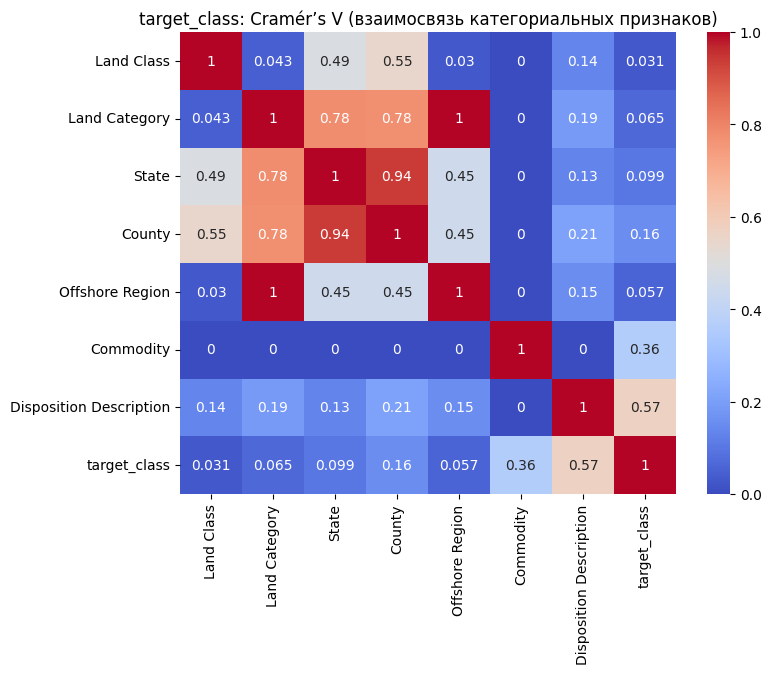

⚠️ Сильно коррелирующие пары (категориальные признаки): [('Land Category', 'State'), ('Land Category', 'County'), ('Land Category', 'Offshore Region'), ('State', 'County')]


In [4]:
df = pd.read_csv('data/OGORB_clean.csv',
                parse_dates=['Production Date'],
                thousands=","
)

df.loc[df['Volume'] > 0, 'target_class'] = 'positive'
df.loc[df['Volume'] == 0, 'target_class'] = 'zero'
df.loc[df['Volume'] < 0, 'target_class'] = 'negative'

df_clf = df.drop(columns=['Production Date', 'FIPS Code', 'Disposition Code', 'Volume'])

# Анализ корреляций
analyze_corr(df_clf, 'target_class')

# Исключаем признак 'Land Category'
df_clf.drop(columns=['Land Category'], axis=1, inplace=True)

Несмотря на наличие мультиколлинеарности между географическими признаками (Land Class, Offshore Region, State, County), в рамках проектного решения сохранены все признаки, кроме признака 'Land Category' польностью дублирующий признак "Offshore Region", так как алгоритмы бустинга (CatBoost, LightGBM, XGBoost) устойчивы к коррелированным признакам и автоматически регулируют их вклад.

Это позволит сохранить пространственную детализацию и не потерять информационную составляющую.

## Подготовка данных для классификации

In [5]:
print("\n" + "="*70)
print("🔥 Train/Val/Test split")
print("="*70)

target_col='target_class'
test_size=0.15
val_size=0.15
random_state=42

X = df_clf.drop(columns=[target_col])
y = df_clf[target_col]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, 
    test_size=test_size,
    stratify=y,
    random_state=random_state
)

val_size_relative = val_size / (1 - test_size)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=val_size_relative,
    stratify=y_train_val,
    random_state=random_state
)

print(f"Train: {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Validation: {X_val.shape[0]} samples ({X_val.shape[0]/len(df)*100:.1f}%)")
print(f"Test: {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"Распределение классов в train: {y_train.value_counts(normalize=True).to_dict()}")
print(f"Распределение классов в validation: {y_val.value_counts(normalize=True).to_dict()}")
print(f"Распределение классов в test: {y_test.value_counts(normalize=True).to_dict()}")


🔥 Train/Val/Test split
Train: 329580 samples (70.0%)
Validation: 70625 samples (15.0%)
Test: 70625 samples (15.0%)
Распределение классов в train: {'zero': 0.6298622489228716, 'positive': 0.34244796407549, 'negative': 0.02768978700163845}
Распределение классов в validation: {'zero': 0.6298619469026548, 'positive': 0.3424566371681416, 'negative': 0.02768141592920354}
Распределение классов в test: {'zero': 0.6298619469026548, 'positive': 0.3424566371681416, 'negative': 0.02768141592920354}


In [6]:
print("\n" + "="*60)
print("ОБУЧЕНИЕ CATBOOST")
print("="*60)

cat_features = [
        'Land Class', 'State', 'County',
        'Offshore Region', 'Commodity', 'Disposition Description'
]

train_pool = catboost.Pool(X_train, y_train, cat_features=cat_features)
val_pool = catboost.Pool(X_val, y_val, cat_features=cat_features)
test_pool = catboost.Pool(X_test, y_test, cat_features=cat_features)

model = catboost.CatBoostClassifier(
    iterations=1000,  
    depth=6,
    learning_rate=0.05,
    loss_function='MultiClass',
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
    use_best_model=True
)

print("\nОбучаем модель...")
model.fit(train_pool, eval_set=val_pool)

y_test_pred = model.predict(test_pool)
model_report = classification_report(y_test, y_test_pred)

print("\n" + "="*40)
print("СРАВНЕНИЕ С БАЗОВЫМИ МОДЕЛЯМИ")
print("="*40)

# Baseline 1: Всегда предсказываем самый частый класс
most_common = y_train.mode()[0]
y_baseline1 = [most_common] * len(y_test)
baseline1_report = classification_report(y_test, y_baseline1)

# Baseline 2: Случайные предсказания с распределением как в train
class_probs = y_train.value_counts(normalize=True).to_dict()
classes = list(class_probs.keys())
probs = list(class_probs.values())
y_baseline2 = np.random.choice(classes, size=len(y_test), p=probs)
baseline2_report = classification_report(y_test, y_baseline2)

print(f"Baseline 1 (Всегда предсказываем самый популярный класс {most_common}):\n {baseline1_report}")
print(f"Baseline 2 (Случайные предсказания с распределением как в train):\n {baseline2_report}")
print(f"CatBoost):\n {model_report}")

# Важность признаков
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nТоп-10 признаков по важности:")
print(feat_imp.head(10))


ОБУЧЕНИЕ CATBOOST

Обучаем модель...
0:	learn: 1.0138250	test: 1.0135768	best: 1.0135768 (0)	total: 1.05s	remaining: 17m 26s
100:	learn: 0.0966538	test: 0.0929109	best: 0.0929109 (100)	total: 55.4s	remaining: 8m 13s
200:	learn: 0.0838609	test: 0.0806073	best: 0.0806073 (200)	total: 1m 48s	remaining: 7m 12s
300:	learn: 0.0796644	test: 0.0768489	best: 0.0768489 (300)	total: 2m 46s	remaining: 6m 26s
400:	learn: 0.0762317	test: 0.0738173	best: 0.0738173 (400)	total: 3m 57s	remaining: 5m 55s
500:	learn: 0.0738196	test: 0.0718052	best: 0.0718052 (500)	total: 5m 12s	remaining: 5m 11s
600:	learn: 0.0727499	test: 0.0711283	best: 0.0711188 (599)	total: 6m 33s	remaining: 4m 20s
700:	learn: 0.0716054	test: 0.0703030	best: 0.0703030 (700)	total: 7m 52s	remaining: 3m 21s
800:	learn: 0.0703783	test: 0.0695076	best: 0.0695076 (800)	total: 8m 50s	remaining: 2m 11s
900:	learn: 0.0693527	test: 0.0689890	best: 0.0689589 (890)	total: 9m 40s	remaining: 1m 3s
999:	learn: 0.0684028	test: 0.0685045	best: 0.06

In [7]:
print("\n" + "="*60)
print("LIGHTGBM")
print("="*60)

X_train_lgbm = X_train.copy()
X_val_lgbm = X_val.copy()
X_test_lgbm = X_test.copy()

categorical_indices = []
for i, col in enumerate(X_train_lgbm.columns):
    if col in cat_features:
        categorical_indices.append(i)
        X_train_lgbm[col] = X_train_lgbm[col].astype('category')
        X_val_lgbm[col] = X_val_lgbm[col].astype('category')
        X_test_lgbm[col] = X_test_lgbm[col].astype('category')

model = lightgbm.LGBMClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    objective='multiclass',
    num_class=3,
    random_state=42,
    verbosity=-1,
    categorical_feature=categorical_indices,
    class_weight='balanced')

model.fit(
    X_train_lgbm, y_train,
    eval_set=[(X_val_lgbm, y_val)],
    eval_metric='multi_logloss',
    callbacks=[lightgbm.early_stopping(50)])

y_pred = model.predict(X_test_lgbm)

print("\nОтчет по классам:")
print(classification_report(y_test, y_pred))

# Важность признаков
feat_imp = pd.DataFrame({
    'Feature': X_train_lgbm.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nТоп-10 признаков по важности:")
print(feat_imp.head(10))


LIGHTGBM
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[991]	valid_0's multi_logloss: 0.0680551

Отчет по классам:
              precision    recall  f1-score   support

    negative       0.62      0.99      0.76      1955
    positive       0.98      0.97      0.98     24186
        zero       1.00      0.97      0.98     44484

    accuracy                           0.97     70625
   macro avg       0.87      0.98      0.91     70625
weighted avg       0.98      0.97      0.98     70625


Топ-10 признаков по важности:
                   Feature  Importance
2                   County       27966
5  Disposition Description       20399
4                Commodity       18633
1                    State        8768
0               Land Class        7432
3          Offshore Region        4210


In [8]:
print("\n" + "="*60)
print("XGBOOST")
print("="*60)

target_encode_cols = ['Disposition Description', 'Commodity', 'State', 'County']

X_train_xgb = X_train.copy()
X_val_xgb = X_val.copy()
X_test_xgb = X_test.copy()

# Кодируем целевую переменную
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)

one_hot_features = [col for col in cat_features if col not in target_encode_cols]

X_train_xgb = pd.get_dummies(X_train_xgb, columns=one_hot_features, drop_first=True)
X_val_xgb = pd.get_dummies(X_val_xgb, columns=one_hot_features, drop_first=True)
X_test_xgb = pd.get_dummies(X_test_xgb, columns=one_hot_features, drop_first=True)
    
for col in target_encode_cols:

    col_encoder = TargetEncoder()
        
    X_train_xgb[col] = col_encoder.fit_transform(X_train_xgb[[col]], y_train_encoded)

    X_val_xgb[col] = col_encoder.transform(X_val_xgb[[col]])
        
    X_test_xgb[col] = col_encoder.transform(X_test_xgb[[col]])

print(f"Размер данных после кодирования: {X_train_xgb.shape}")
print(f"Размер данных после кодирования: {X_val_xgb.shape}")
print(f"Размер данных после кодирования: {X_test_xgb.shape}")

model = xgboost.XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss',
    early_stopping_rounds=50
)
model.fit(
    X_train_xgb, y_train_encoded,
    eval_set=[(X_val_xgb, y_val_encoded)],
    verbose=100
)

y_pred = model.predict(X_test_xgb)

print("\nОтчет по классам:")
print(classification_report(y_test_encoded, y_pred))

# Важность признаков
feat_imp = pd.DataFrame({
    'Feature': X_train_xgb.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nТоп-10 признаков по важности:")
print(feat_imp.head(10))


XGBOOST
Размер данных после кодирования: (329580, 9)
Размер данных после кодирования: (70625, 9)
Размер данных после кодирования: (70625, 9)
[0]	validation_0-mlogloss:0.92614
[100]	validation_0-mlogloss:0.57274
[200]	validation_0-mlogloss:0.55795
[300]	validation_0-mlogloss:0.55525
[400]	validation_0-mlogloss:0.55423
[500]	validation_0-mlogloss:0.55368
[600]	validation_0-mlogloss:0.55329
[700]	validation_0-mlogloss:0.55301
[800]	validation_0-mlogloss:0.55284
[848]	validation_0-mlogloss:0.55295

Отчет по классам:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1955
           1       0.60      0.52      0.56     24186
           2       0.75      0.81      0.78     44484

    accuracy                           0.71     70625
   macro avg       0.73      0.71      0.72     70625
weighted avg       0.70      0.71      0.70     70625


Топ-10 признаков по важности:
                            Feature  Importance
3           Dispositi

## 🧾 Итоговые выводы по классификационному анализу

### 🎯 Цель эксперимента (напоминание)

Данный классификационный анализ **не является основной задачей проекта**, а используется как **проверка гипотезы**:

> *Категориальные признаки `Disposition Description` и `Commodity` содержат достаточно информации,  
> чтобы объяснить принадлежность записи к одной из категорий объёма:*
> **positive / zero / negative**.

Результаты этого анализа используются для:
- интерпретации EDA,
- обоснования агрегации данных,
- корректного формирования целевых временных рядов для прогнозирования.

---

## ✅ Подтверждение гипотезы

Результаты всех трёх моделей однозначно показывают, что гипотеза **подтверждена**.

- Категории объёма (**positive / zero / negative**) **почти полностью детерминируются**:
  - типом операции (`Disposition Description`);
  - типом ресурса (`Commodity`);
  - географическими атрибутами (State, County, Offshore Region).

Особенно показательно:
- **CatBoost и LightGBM** достигают **F1-score ≈ 0.97–0.98**;
- даже редкий класс **negative (<3%)** распознаётся с высокой полнотой (recall ≈ 0.99).

Это означает, что:
- нулевые и отрицательные объёмы **не являются шумом или ошибками**;
- они системно связаны с бизнес-логикой учёта и регуляторной отчётностью.

---

## 📊 Сравнение моделей и кодирования признаков

### 1. CatBoost и LightGBM — лучшие результаты

| Модель | Accuracy | Macro F1 |
|------|----------|----------|
| **CatBoost** | ~0.97 | ~0.90 |
| **LightGBM** | ~0.97 | ~0.91 |
| XGBoost | ~0.71 | ~0.72 |

**Причина превосходства CatBoost и LightGBM**:
- нативная поддержка категориальных признаков;
- автоматическое и устойчивое кодирование категорий;
- корректная работа с несбалансированными классами.

---

### 2. Почему XGBoost показал худший результат

Несмотря на использование:
- one-hot encoding;
- target encoding;

модель XGBoost значительно уступает по качеству.

Ключевые причины:
- **Target Encoding** чувствителен к:
  - сильной несбалансированности классов;
  - большим кардинальностям (County, State);
  - leakage-эффектам и смещению средних.
- One-hot encoding увеличивает размерность и ухудшает обобщающую способность.

➡️ В данном контексте **ручное кодирование категорий проигрывает встроенным механизмам CatBoost и LightGBM**.

---

## 🔍 Важность признаков: интерпретация

Во всех моделях лидируют одни и те же признаки:

1. **Disposition Description** — ключевой фактор (≈ 35–45%)
2. **Commodity** — второй по значимости признак
3. География:
   - County
   - State
   - Offshore Region

Это подтверждает:
- операции OGOR имеют **жёстко заданную семантику**;
- тип операции почти однозначно определяет знак объёма.

---

## 🧠 Методологический вывод

Данный эксперимент показывает, что:

1. **Классификация знака объёма тривиальна**, если известны:
   - тип операции;
   - тип ресурса.

2. Использование этих данных **в “сыром” виде** для временных рядов:
   - приводит к искажению распределений;
   - маскирует реальные тренды и сезонность.

3. Следовательно:
   - нулевые и отрицательные значения **не должны моделироваться напрямую**;
   - корректный подход — **агрегация месячных объёмов** и работа с итоговой целевой переменной.

---

## 🔗 Связь с основной задачей проекта

Результаты классификационного анализа напрямую обосновывают принятые решения в основном пайплайне:

- переход от транзакционных данных OGOR к **агрегированным временным рядам**;
- отказ от моделирования знака объёма;
- фокус на **прогнозировании суммарных месячных объёмов добычи**;
- выбор моделей **Exponential Smoothing** и **Prophet** как наиболее адекватных поставленной задаче.

📌 Таким образом, данный ноутбук выполняет роль **валидации гипотез EDA**,  
а не самостоятельной ML-задачи.

---

### 🧾 Итог

> **Disposition Description + Commodity → практически полностью объясняют знак объёма.**  
>  
> Это делает классификацию вспомогательным, но критически важным этапом,  
> подтверждающим корректность всей последующей аналитики и прогнозирования.
